# Lesson 15 — Noise Handling and High-Dimensional Inputs

So far our benchmarks used noise-free evaluations in low dimensions (1D, 2D). Real optimisation problems are almost always noisy and often high-dimensional.

This lesson tests how each surrogate responds to:
- **Observation noise** — each evaluation returns f(x) + ε, ε ~ N(0, σ²)
- **High-dimensional inputs** — d = 5 and d = 10 on the Ackley function

The SCR ≤ 20% enforcer from Lessons 13–14 is unchanged.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.stats import norm as sp_norm
from scipy.stats.qmc import LatinHypercube
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.ensemble import RandomForestRegressor
from scipy.interpolate import RBFInterpolator

warnings.filterwarnings('ignore')

RANDOM_SEED  = 42
N_INIT       = 15
N_INIT_5D    = 20
N_INIT_10D   = 30
N_ITER       = 20
N_ITER_5D    = 15
N_ITER_10D   = 10
N_SEEDS      = 3
SCR_MAX      = 0.20
EPOCHS_VIZ   = 2000
EPOCHS_BO    = 500
EPOCHS_HD    = 300
N_MEMBERS    = 5
T_DROPOUT    = 50
NOISE_VIZ    = 0.5
NOISE_LEVELS = [0.0, 0.1, 0.5, 1.0, 2.0]

SURROGATES = ['gp', 'mc_dropout', 'deep_ensemble', 'rbf', 'rf']
LABELS     = ['GP', 'MC Dropout', 'Deep Ensemble', 'RBF', 'Random Forest']
COLORS     = ['steelblue', 'seagreen', 'darkorange', 'tomato', 'purple']

FORRESTER_OPT = -6.020740
ACKLEY_OPT    =  0.0

## Benchmark functions

**Forrester (1D)** — same as previous lessons; the noisy version adds Gaussian noise at evaluation time.

**Ackley (d-dimensional)** — standard multimodal benchmark with many local minima. The global minimum is f* = 0 at the origin (mapped from x = [0.5, …, 0.5] in [0,1]^d). It is a common stress-test for surrogates in higher dimensions.

In [2]:
def forrester(x):
    x = float(np.asarray(x).ravel()[0])
    return (6*x - 2)**2 * np.sin(12*x - 4)


def ackley(x):
    x = np.asarray(x).ravel()
    d = len(x)
    z = x * 10 - 5
    t1 = -20.0 * np.exp(-0.2 * np.sqrt(np.sum(z**2) / d))
    t2 = -np.exp(np.sum(np.cos(2 * np.pi * z)) / d)
    return float(t1 + t2 + 20.0 + np.e)


# Quick sanity check
print(f'Forrester at optimum x≈0.757: {forrester(0.757):.4f}  (target ≈ {FORRESTER_OPT})')
print(f'Ackley at origin (1D):        {ackley([0.5]):.6f}  (target = 0.0)')
print(f'Ackley at origin (5D):        {ackley([0.5]*5):.6f}')

Forrester at optimum x≈0.757: -6.0207  (target ≈ -6.02074)
Ackley at origin (1D):        0.000000  (target = 0.0)
Ackley at origin (5D):        0.000000


## Neural network architecture and surrogate implementations

Same unified interface as Lesson 14: `surrogate_predict(stype, X_tr, y_tr, X_cand, seed, epochs) → μ, σ`.

In [3]:
class Net(nn.Module):
    def __init__(self, d_in, p=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 64), nn.ReLU(), nn.Dropout(p),
            nn.Linear(64, 64),   nn.ReLU(), nn.Dropout(p),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_net(X, y, epochs, seed):
    torch.manual_seed(seed)
    model = Net(X.shape[1])
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    Xt    = torch.tensor(X, dtype=torch.float32)
    yt    = torch.tensor(y, dtype=torch.float32)
    model.train()
    for _ in range(epochs):
        opt.zero_grad()
        nn.MSELoss()(model(Xt), yt).backward()
        opt.step()
    return model


def surrogate_predict(stype, X_tr, y_tr, X_cand, seed=0, epochs=500):
    torch.manual_seed(seed)

    if stype == 'gp':
        kernel = Matern(nu=2.5, length_scale_bounds=(1e-3, 10.0))
        gpr = GaussianProcessRegressor(
            kernel=kernel, alpha=1e-4,
            n_restarts_optimizer=2, normalize_y=True, random_state=seed,
        )
        gpr.fit(X_tr, y_tr)
        mu, std = gpr.predict(X_cand, return_std=True)
        return mu, np.maximum(std, 1e-8)

    if stype == 'mc_dropout':
        model = train_net(X_tr, y_tr, epochs, seed)
        model.train()
        Xc = torch.tensor(X_cand, dtype=torch.float32)
        with torch.no_grad():
            preds = np.stack([model(Xc).numpy() for _ in range(T_DROPOUT)])
        return preds.mean(0), np.maximum(preds.std(0), 1e-8)

    if stype == 'deep_ensemble':
        preds = []
        for i in range(N_MEMBERS):
            m  = train_net(X_tr, y_tr, epochs, seed + i * 17)
            m.eval()
            Xc = torch.tensor(X_cand, dtype=torch.float32)
            with torch.no_grad():
                preds.append(m(Xc).numpy())
        preds = np.stack(preds)
        return preds.mean(0), np.maximum(preds.std(0), 1e-8)

    if stype == 'rbf':
        rbf = RBFInterpolator(X_tr, y_tr, kernel='thin_plate_spline', smoothing=1e-3)
        mu  = rbf(X_cand)
        diffs = X_cand[:, None, :] - X_tr[None, :, :]
        min_d = np.linalg.norm(diffs, axis=-1).min(axis=1)
        std   = min_d / (min_d.max() + 1e-8) + 0.05
        return mu, std

    if stype == 'rf':
        rf = RandomForestRegressor(n_estimators=100, random_state=seed)
        rf.fit(X_tr, y_tr)
        preds = np.stack([t.predict(X_cand) for t in rf.estimators_])
        return preds.mean(0), np.maximum(preds.std(0), 1e-8)

    raise ValueError(f'Unknown surrogate: {stype}')

## SCR-enforced BO loop

Same enforcer as Lessons 13–14:

```
proj_SCR = (surr_calls + 1) / (true_calls + surr_calls + 1)
use_surrogate = (proj_SCR ≤ SCR_MAX)
```

The `noise_std` parameter adds Gaussian noise to each true evaluation.

In [4]:
def ei(mu, std, best, xi=0.01):
    imp = best - mu - xi
    z   = imp / (std + 1e-8)
    return imp * sp_norm.cdf(z) + std * sp_norm.pdf(z)


def run_bo(stype, func, dim, seed, f_opt,
           n_init, n_iter, epochs=EPOCHS_BO, noise_std=0.0, scr_max=SCR_MAX):
    rng = np.random.RandomState(seed)

    sampler = LatinHypercube(d=dim, seed=seed)
    X_obs   = sampler.random(n_init)
    y_obs   = np.array([func(x) + rng.normal(0, noise_std) for x in X_obs])

    true_calls = n_init
    surr_calls = 0
    best_true  = y_obs.min()
    history    = [(true_calls, max(best_true - f_opt, 0.0))]

    for _ in range(n_iter):
        y_mean = y_obs.mean()
        y_sc   = y_obs.std() + 1e-8
        y_std  = (y_obs - y_mean) / y_sc

        X_cand      = rng.rand(200, dim)
        mu_s, sig_s = surrogate_predict(stype, X_obs, y_std, X_cand, seed, epochs)
        mu          = mu_s  * y_sc + y_mean
        sig         = sig_s * y_sc

        acq             = ei(mu, sig, best_true)
        idx             = np.argmax(acq)
        x_next, mu_next = X_cand[idx], mu[idx]

        proj     = (surr_calls + 1) / (true_calls + surr_calls + 1)
        use_surr = (scr_max > 0) and (proj <= scr_max)

        if use_surr:
            y_next = mu_next
            surr_calls += 1
        else:
            y_next = func(x_next) + rng.normal(0, noise_std)
            true_calls += 1
            best_true = min(best_true, y_next)

        X_obs = np.vstack([X_obs, x_next])
        y_obs = np.append(y_obs, y_next)
        history.append((true_calls, max(best_true - f_opt, 0.0)))

    return history


def run_seeds(stype, func, dim, f_opt, n_init, n_iter, epochs, noise_std=0.0):
    return [
        run_bo(stype, func, dim, RANDOM_SEED + s, f_opt,
               n_init=n_init, n_iter=n_iter, epochs=epochs, noise_std=noise_std)
        for s in range(N_SEEDS)
    ]


def plot_convergence(ax, results_per_surrogate, n_init, title):
    for hists, label, color in zip(results_per_surrogate, LABELS, COLORS):
        max_tc = max(h[-1][0] for h in hists)
        grid   = np.arange(n_init, max_tc + 1)
        runs   = np.array([
            np.interp(grid, [h[0] for h in hist], [h[1] for h in hist])
            for hist in hists
        ])
        med = np.median(runs, axis=0)
        lo  = np.percentile(runs, 25, axis=0)
        hi  = np.percentile(runs, 75, axis=0)
        ax.semilogy(grid, np.maximum(med, 1e-6), color=color, label=label, lw=2)
        ax.fill_between(grid, np.maximum(lo, 1e-6), np.maximum(hi, 1e-6),
                        alpha=0.2, color=color)
    ax.set_xlabel('True function calls')
    ax.set_ylabel('Gap to optimum (log scale)')
    ax.set_title(title)
    ax.legend(fontsize=9)

---
## Part 1 — Noisy Forrester fit

Fit all 5 surrogates to 15 training points corrupted by Gaussian noise (σ = 0.5).

**What to look for:**
- GP produces a smooth posterior that averages over the noise
- RBF interpolates exactly through the noisy points — the fit wiggles with the noise
- MC Dropout and Deep Ensembles behave similarly; they smooth somewhat but can still overfit to noise
- Random Forest naturally averages across trees, giving moderate noise robustness

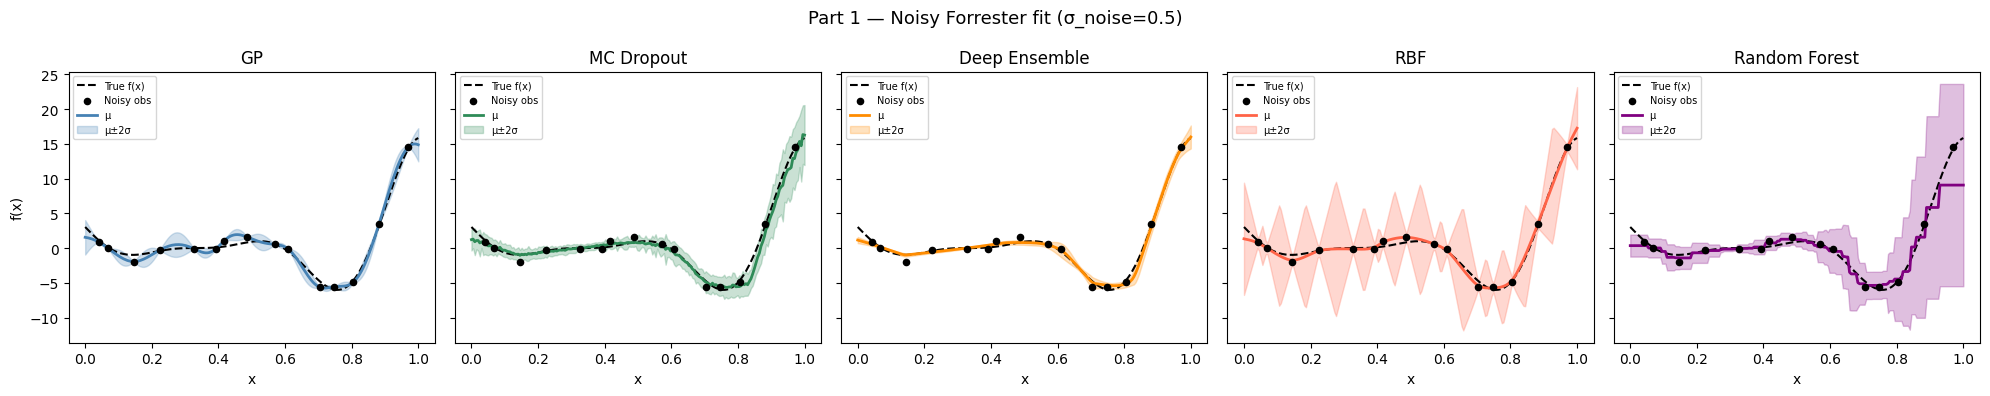

In [5]:
rng     = np.random.RandomState(RANDOM_SEED)
sampler = LatinHypercube(d=1, seed=RANDOM_SEED)
X_tr    = sampler.random(N_INIT).reshape(-1, 1)
y_clean = np.array([forrester(x) for x in X_tr])
y_noisy = y_clean + rng.normal(0, NOISE_VIZ, size=len(y_clean))

y_mean, y_sc = y_noisy.mean(), y_noisy.std() + 1e-8
y_std        = (y_noisy - y_mean) / y_sc

X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
y_true = np.array([forrester(x) for x in X_plot])

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, stype, label, color in zip(axes, SURROGATES, LABELS, COLORS):
    mu_s, sig_s = surrogate_predict(stype, X_tr, y_std, X_plot, RANDOM_SEED, EPOCHS_VIZ)
    mu  = mu_s  * y_sc + y_mean
    sig = sig_s * y_sc
    ax.plot(X_plot, y_true, 'k--', lw=1.5, label='True f(x)')
    ax.scatter(X_tr, y_noisy, c='k', s=20, zorder=5, label='Noisy obs')
    ax.plot(X_plot, mu, color=color, lw=2, label='μ')
    ax.fill_between(X_plot.ravel(), mu - 2*sig, mu + 2*sig,
                    alpha=0.25, color=color, label='μ±2σ')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('x')
    if ax is axes[0]:
        ax.set_ylabel('f(x)')
    ax.legend(fontsize=7)

fig.suptitle(f'Part 1 — Noisy Forrester fit (σ_noise={NOISE_VIZ})', fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 2 — Noise level sweep

Vary σ_noise ∈ {0.0, 0.1, 0.5, 1.0, 2.0}. For each level, fit each surrogate to 15 noisy training points, then measure RMSE on 200 noise-free test points.

**Expected pattern:** RBF RMSE rises steeply; GP and RF are more stable.

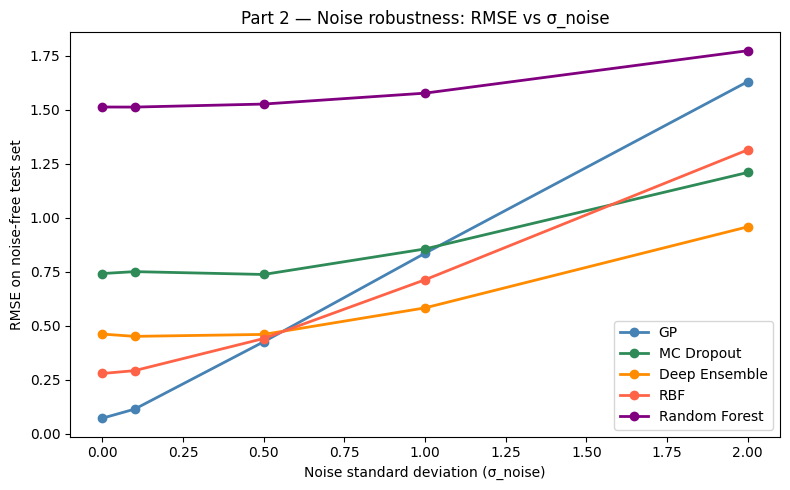

In [6]:
sampler = LatinHypercube(d=1, seed=RANDOM_SEED)
X_tr    = sampler.random(N_INIT).reshape(-1, 1)
y_clean = np.array([forrester(x) for x in X_tr])
X_test  = np.linspace(0, 1, 200).reshape(-1, 1)
y_true  = np.array([forrester(x) for x in X_test])

rmse = {s: [] for s in SURROGATES}
for sigma in NOISE_LEVELS:
    rng_n   = np.random.RandomState(RANDOM_SEED + 99)
    y_noisy = y_clean + rng_n.normal(0, sigma, size=len(y_clean))
    y_mean, y_sc = y_noisy.mean(), y_noisy.std() + 1e-8
    y_std        = (y_noisy - y_mean) / y_sc
    for stype in SURROGATES:
        mu_s, _ = surrogate_predict(stype, X_tr, y_std, X_test, RANDOM_SEED, EPOCHS_VIZ)
        mu      = mu_s * y_sc + y_mean
        rmse[stype].append(np.sqrt(np.mean((mu - y_true)**2)))

fig, ax = plt.subplots(figsize=(8, 5))
for stype, label, color in zip(SURROGATES, LABELS, COLORS):
    ax.plot(NOISE_LEVELS, rmse[stype], 'o-', label=label, color=color, lw=2)
ax.set_xlabel('Noise standard deviation (σ_noise)')
ax.set_ylabel('RMSE on noise-free test set')
ax.set_title('Part 2 — Noise robustness: RMSE vs σ_noise')
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 3 — BO convergence under noise (Forrester 1D)

Full SCR-enforced BO on the noisy Forrester function (σ = 0.5, 3 seeds, 20 iterations).

**X-axis = true function calls only** (COCO-correct). Surrogate-only steps do not count.

Note: the y-axis gap is measured using the best *true* evaluation seen so far, not the surrogate prediction.

Running noisy 1D BO...
  GP...
  MC Dropout...
  Deep Ensemble...
  RBF...
  Random Forest...


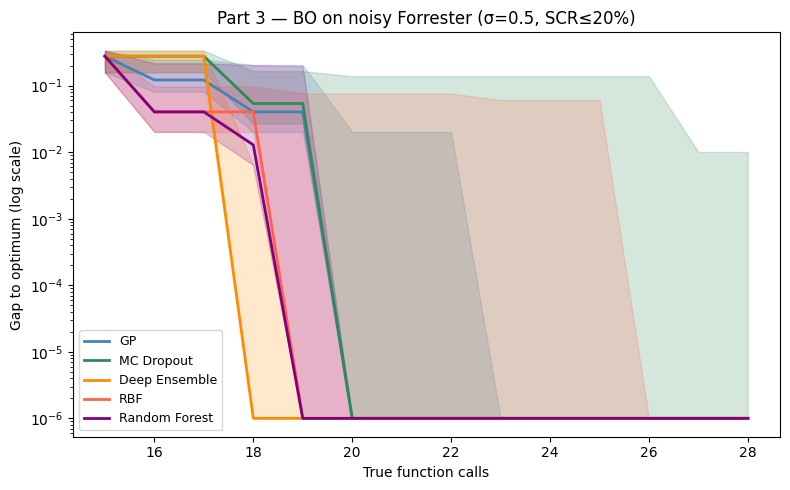

In [7]:
print('Running noisy 1D BO...')
res_noisy = {}
for stype, label in zip(SURROGATES, LABELS):
    print(f'  {label}...')
    res_noisy[stype] = run_seeds(stype, forrester, 1, FORRESTER_OPT,
                                 N_INIT, N_ITER, EPOCHS_BO, NOISE_VIZ)

fig, ax = plt.subplots(figsize=(8, 5))
plot_convergence(ax, [res_noisy[s] for s in SURROGATES], N_INIT,
                 f'Part 3 — BO on noisy Forrester (σ={NOISE_VIZ}, SCR≤{int(SCR_MAX*100)}%)')
plt.tight_layout()
plt.show()

---
## Part 4 — BO on Ackley (d=5)

The Ackley function in 5 dimensions has many local minima. With 20 initial LHS points and 15 BO iterations, the budget is tight.

**What to look for:**
- GP still competitive at d=5 with an isotropic Matérn kernel
- RBF uncertainty proxy (distance to nearest neighbour) degrades as space becomes sparser
- Neural networks need enough initial data to generalise in higher dimensions

Running Ackley 5D BO...
  GP...
  MC Dropout...
  Deep Ensemble...
  RBF...
  Random Forest...


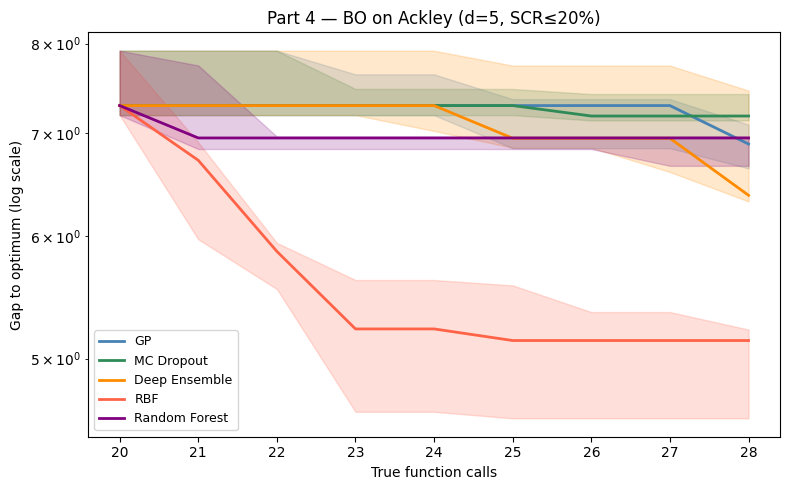

In [8]:
print('Running Ackley 5D BO...')
res_5d = {}
for stype, label in zip(SURROGATES, LABELS):
    print(f'  {label}...')
    res_5d[stype] = run_seeds(stype, ackley, 5, ACKLEY_OPT,
                              N_INIT_5D, N_ITER_5D, EPOCHS_HD)

fig, ax = plt.subplots(figsize=(8, 5))
plot_convergence(ax, [res_5d[s] for s in SURROGATES], N_INIT_5D,
                 f'Part 4 — BO on Ackley (d=5, SCR≤{int(SCR_MAX*100)}%)')
plt.tight_layout()
plt.show()

---
## Part 5 — BO on Ackley (d=10)

Pushing to d=10 with 30 initial points and only 10 BO iterations.

At d=10, the 30 initial LHS points cover [0,1]^10 very sparsely. All surrogates struggle, but the relative ranking reveals which methods generalise best from limited high-dimensional data.

The **curse of dimensionality** is most visible here: the nearest-neighbour distances grow, EI has a rough landscape, and the surrogate is trained on very few points relative to the volume.

Running Ackley 10D BO...
  GP...
  MC Dropout...
  Deep Ensemble...
  RBF...
  Random Forest...


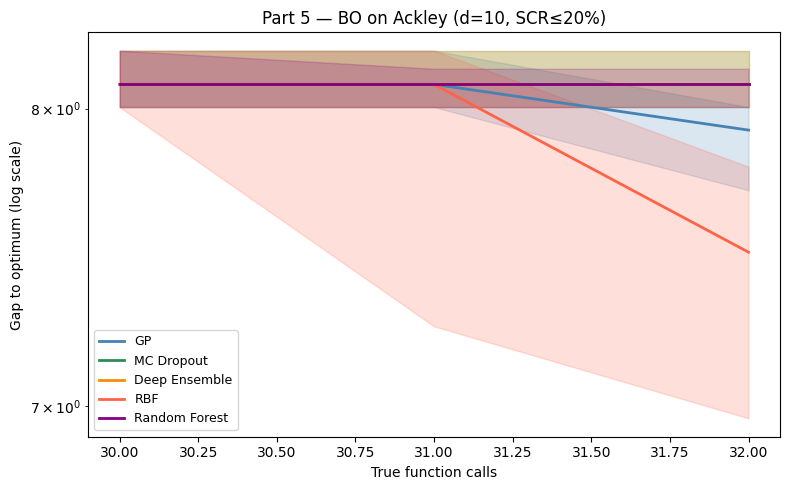

In [9]:
print('Running Ackley 10D BO...')
res_10d = {}
for stype, label in zip(SURROGATES, LABELS):
    print(f'  {label}...')
    res_10d[stype] = run_seeds(stype, ackley, 10, ACKLEY_OPT,
                               N_INIT_10D, N_ITER_10D, EPOCHS_HD)

fig, ax = plt.subplots(figsize=(8, 5))
plot_convergence(ax, [res_10d[s] for s in SURROGATES], N_INIT_10D,
                 f'Part 5 — BO on Ackley (d=10, SCR≤{int(SCR_MAX*100)}%)')
plt.tight_layout()
plt.show()

---
## Part 6 — Leaderboard

Final gap to optimum (median over 3 seeds) across all three experiments:
- Noisy Forrester (1D)
- Ackley (d=5)
- Ackley (d=10)

Smaller bar = better. Look for which surrogate is most consistent across all three challenges.

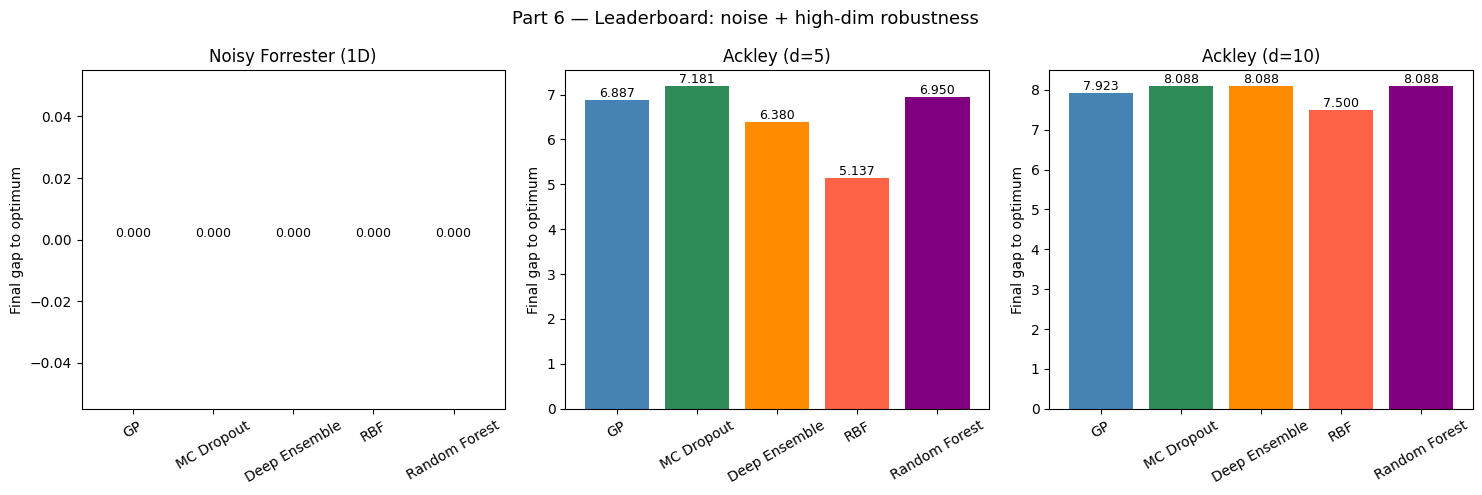

Surrogate            Noisy 1D         5D        10D
----------------------------------------------------
GP                     0.0000     6.8872     7.9230
MC Dropout             0.0000     7.1813     8.0875
Deep Ensemble          0.0000     6.3798     8.0875
RBF                    0.0000     5.1367     7.5002
Random Forest          0.0000     6.9499     8.0875


In [10]:
def final_gap(hists):
    return float(np.median([h[-1][1] for h in hists]))


tasks = [
    ('Noisy Forrester (1D)', res_noisy),
    ('Ackley (d=5)',         res_5d),
    ('Ackley (d=10)',        res_10d),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, res) in zip(axes, tasks):
    vals = [final_gap(res[s]) for s in SURROGATES]
    bars = ax.bar(LABELS, vals, color=COLORS)
    ax.set_ylabel('Final gap to optimum')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Part 6 — Leaderboard: noise + high-dim robustness', fontsize=13)
plt.tight_layout()
plt.show()

print(f"{'Surrogate':<18} {'Noisy 1D':>10} {'5D':>10} {'10D':>10}")
print('-' * 52)
for s, label in zip(SURROGATES, LABELS):
    print(f"{label:<18} {final_gap(res_noisy[s]):>10.4f} "
          f"{final_gap(res_5d[s]):>10.4f} {final_gap(res_10d[s]):>10.4f}")

---
## Exercises

1. **Part 2** — Which surrogate has the steepest RMSE rise as σ_noise increases? What property of that surrogate causes this behaviour?

2. **Part 4** — Change `N_INIT_5D = 10` and re-run Part 4. Does the ranking of surrogates change when they start with less data?

3. **Part 5** — GP often degrades at d=10 with `n_restarts_optimizer=2`. Try increasing it to 5. Does it help, or is the fundamental problem the isotropic length scale assumption (one length scale for all 10 dimensions)?